In [1]:
import pandas as pd

# Load correct files
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [2]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [3]:
print(sentiment.head())
print(sentiment.columns)

print(trades.head())
print(trades.columns)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')
                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side     timestamp ist  start position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986

In [4]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['time'] = pd.to_datetime(trades['time'])

KeyError: 'time'

In [5]:
print(trades.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='str')


In [6]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')"

SyntaxError: unterminated string literal (detected at line 2) (1787695741.py, line 2)

In [7]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

In [8]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['date'] = trades['timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [9]:
merged = pd.merge(trades, sentiment, on='date', how='left')
merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN


In [10]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], format='%d-%m-%Y %H:%M')

In [11]:
trades['date'] = trades['timestamp_ist'].dt.date

In [12]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [13]:
merged = pd.merge(trades, sentiment, on='date', how='left')

In [14]:
merged[['timestamp_ist', 'date', 'classification']].head()

,timestamp_ist,date,classification
0,2024-12-02 22:50:00,2024-12-02,Extreme Greed
1,2024-12-02 22:50:00,2024-12-02,Extreme Greed
2,2024-12-02 22:50:00,2024-12-02,Extreme Greed
3,2024-12-02 22:50:00,2024-12-02,Extreme Greed
4,2024-12-02 22:50:00,2024-12-02,Extreme Greed


In [15]:
merged['profit'] = merged['closed_pnl']

In [16]:
merged['win'] = merged['profit'] > 0

In [17]:
merged['position_value'] = merged['size_usd']

In [18]:
merged['side'] = merged['side'].map({'BUY': 1, 'SELL': -1})

In [19]:
merged.groupby('classification')['profit'].mean().sort_values()

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: profit, dtype: float64

In [20]:
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [21]:
merged.groupby('classification')['position_value'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: position_value, dtype: float64

In [22]:
merged.groupby(['date','classification']).size()

date        classification
2023-05-01  Greed                3
2023-12-05  Extreme Greed        9
2023-12-14  Greed               11
2023-12-15  Greed                2
2023-12-16  Greed                3
                              ... 
2025-04-27  Greed              337
2025-04-28  Neutral           1379
2025-04-29  Greed             2243
2025-04-30  Greed             1113
2025-05-01  Neutral           1230
Length: 479, dtype: int64

In [23]:
top = merged.groupby('account')['profit'].sum().sort_values(ascending=False).head(10)

In [24]:
merged[merged['account'].isin(top.index)].groupby('classification')['profit'].mean()

classification
Extreme Fear      60.765008
Extreme Greed    136.960455
Fear              66.979192
Greed             93.526109
Neutral           53.831636
Name: profit, dtype: float64

In [25]:
merged.groupby('classification')['profit'].mean()
merged.groupby('classification')['win'].mean()
merged.groupby('classification')['position_value'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: position_value, dtype: float64

In [26]:
merged.groupby('classification')['profit'].mean()
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [27]:
merged.groupby('classification')['profit'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: profit, dtype: float64

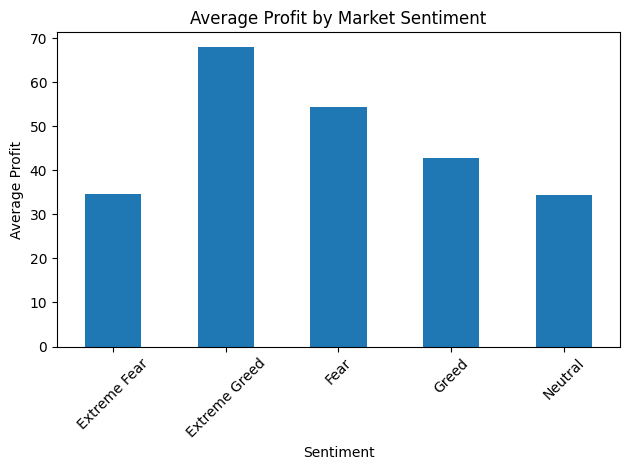

In [28]:
import matplotlib.pyplot as plt

profit = merged.groupby('classification')['profit'].mean()

plt.figure()
profit.plot(kind='bar')
plt.title('Average Profit by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

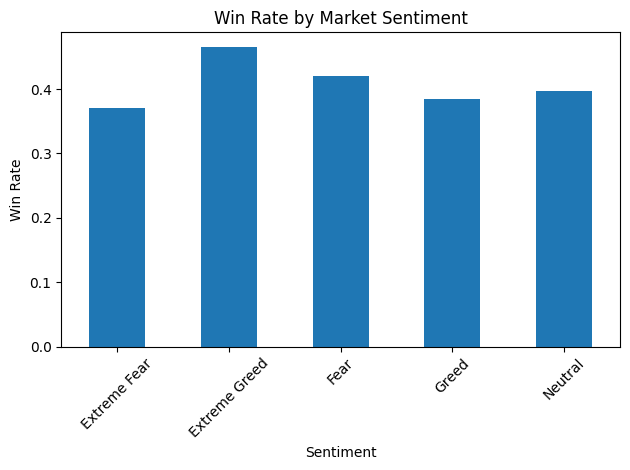

In [29]:
win_rate = merged.groupby('classification')['win'].mean()

plt.figure()
win_rate.plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

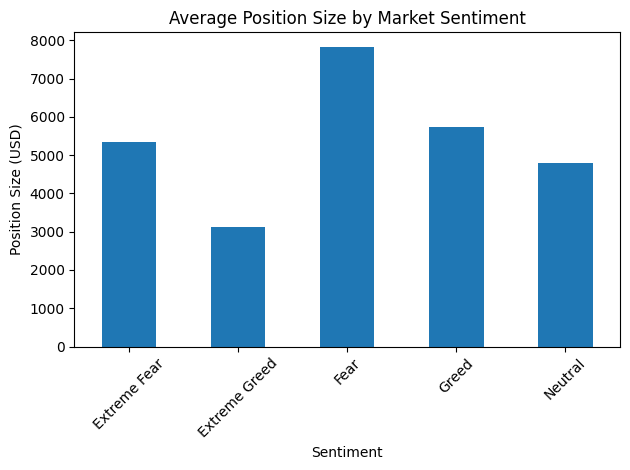

In [30]:
position = merged.groupby('classification')['position_value'].mean()

plt.figure()
position.plot(kind='bar')
plt.title('Average Position Size by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Position Size (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

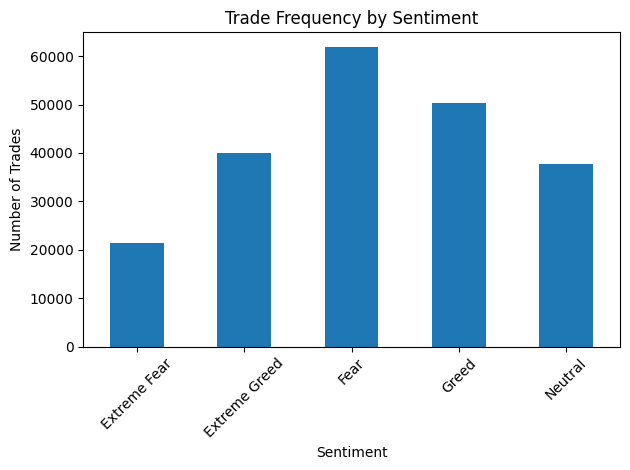

In [31]:
freq = merged.groupby('classification').size()

plt.figure()
freq.plot(kind='bar')
plt.title('Trade Frequency by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()